# Data Analysis for SD-GPGPU2026 Submission, II - CDF of Execution-Level Variation 

Redo Figure 1 with the per-device FP16 and badwidth max/mean, min/mean, where each GPU device is identified by a (`gpu_id`, `provider`) pair. Find:

- Number of GPU ID: 3534
- Number of entries: 6809
- Number of GPUs occurring more than 3 (including 3) times: 736
- The maximum GPU fp16 spread $(max - min)/mean$: 8.37%
- The maximum GPU d2d_bw spread: 9.72%
- Percentage of GPUs with d2d_bw spread <= 2%: 92.12%
- Percentage of GPUs with fp16 spread <= 2%: 82.74%

Plot a CDF chart as Prof. Sun described that most of the GPU devices have very low per-device variation. Sort the GPU devices according to their $(max - min)/mean$ (x-axis).

In [1]:
%pip install pandas matplotlib seaborn scipy --quiet

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd

df_raw = pd.read_csv('all_providers_data_2025-12-18.csv', sep=',')

In [3]:
# Group by gpu_id and check consistency of provider and gpu_model
gpu_id_groups = df_raw.groupby('gpu_id').agg({
    'provider': lambda x: x.nunique(),
    'gpu_model': lambda x: x.nunique()
}).rename(columns={'provider': 'provider_count', 'gpu_model': 'gpu_model_count'})

# Find gpu_ids with multiple different providers or gpu_models
inconsistent = gpu_id_groups[(gpu_id_groups['provider_count'] > 1) | (gpu_id_groups['gpu_model_count'] > 1)]

print(f"Total number of gpu_ids: {len(gpu_id_groups)}")
print(f"Number of gpu_ids with inconsistencies: {len(inconsistent)}")
print("\nDetailed inconsistencies:")

num = 0

if len(inconsistent) > 0:
    for idx, (gpu_id, row) in enumerate(inconsistent.iterrows()):
        # print(f"\n--- gpu_id #{idx+1}: {gpu_id} ---")
        gpu_data = df_raw[df_raw['gpu_id'] == gpu_id][['provider', 'gpu_model']].drop_duplicates()
        # print(f"Different provider/gpu_model combinations for this gpu_id:")
        num += 1
        # for i, data_row in gpu_data.iterrows():
            # print(f"  provider: {data_row['provider']}, gpu_model: {data_row['gpu_model']}")
else:
    print("No inconsistencies found. Each gpu_id corresponds to a unique provider and gpu_model.")

print(f"\nTotal number of inconsistent entries found: {num}")

Total number of gpu_ids: 3513
Number of gpu_ids with inconsistencies: 21

Detailed inconsistencies:

Total number of inconsistent entries found: 21


In [4]:
# Add suffix "_1" to duplicate gpu_ids from different providers
# For gpu_ids that appear in multiple providers, add "_1" to non-first providers

def add_suffix_to_duplicate_gpu_ids(df):
    """
    For each gpu_id that appears in multiple providers,
    add "_1" suffix to gpu_ids from the second and subsequent providers.
    
    The first occurrence of each gpu_id keeps the original name.
    """
    df_modified = df.copy()
    
    # Find gpu_ids that appear with multiple providers
    gpu_id_providers = df_modified.groupby('gpu_id')['provider'].nunique()
    duplicate_gpu_ids = gpu_id_providers[gpu_id_providers > 1].index
    
    print(f"Total gpu_ids with multiple providers: {len(duplicate_gpu_ids)}")
    
    # For each duplicate gpu_id, mark which provider gets the suffix
    for gpu_id in duplicate_gpu_ids:
        mask = df_modified['gpu_id'] == gpu_id
        rows_with_gpu_id = df_modified[mask].copy()
        
        # Sort by provider to ensure consistent ordering
        rows_with_gpu_id = rows_with_gpu_id.sort_values('provider')
        providers_list = rows_with_gpu_id['provider'].unique()
        
        print(f"\ngpu_id: {gpu_id}")
        print(f"  Providers: {list(providers_list)}")
        
        # For each provider except the first, add "_1" suffix
        for idx, provider in enumerate(providers_list):
            if idx > 0:  # Skip the first provider
                # Find rows with this gpu_id and provider, and add suffix
                mask_for_suffix = (df_modified['gpu_id'] == gpu_id) & (df_modified['provider'] == provider)
                df_modified.loc[mask_for_suffix, 'gpu_id'] = gpu_id + '_1'
                print(f"    {provider}: gpu_id changed to {gpu_id}_1")
    
    return df_modified

# Apply the function
df_raw = add_suffix_to_duplicate_gpu_ids(df_raw)

print("\n" + "="*80)
print("Data processing completed!")
print(f"Original shape: {df_raw.shape}")
print(f"Processed shape: {df_raw.shape}")
print("\nSample of modified gpu_ids:")
print(df_raw[['provider', 'gpu_id', 'gpu_model']].drop_duplicates('gpu_id').head(25))

Total gpu_ids with multiple providers: 21

gpu_id: GPU-1181aa87-9d80-6286-3e00-a0c56019d9d7
  Providers: ['lambda', 'paperspace']
    paperspace: gpu_id changed to GPU-1181aa87-9d80-6286-3e00-a0c56019d9d7_1

gpu_id: GPU-13af2717-7443-4f65-459d-49e4ad45578c
  Providers: ['lambda', 'paperspace']
    paperspace: gpu_id changed to GPU-13af2717-7443-4f65-459d-49e4ad45578c_1

gpu_id: GPU-18d895e6-f7f5-512a-b45e-d44ee20dfc5c
  Providers: ['lambda', 'paperspace']
    paperspace: gpu_id changed to GPU-18d895e6-f7f5-512a-b45e-d44ee20dfc5c_1

gpu_id: GPU-1b2bfb26-0030-7236-2a71-c51de359518f
  Providers: ['lambda', 'paperspace']
    paperspace: gpu_id changed to GPU-1b2bfb26-0030-7236-2a71-c51de359518f_1

gpu_id: GPU-32af726d-bd07-4891-5852-6e7c56bdc16c
  Providers: ['lambda', 'paperspace']
    paperspace: gpu_id changed to GPU-32af726d-bd07-4891-5852-6e7c56bdc16c_1

gpu_id: GPU-3c5f1afe-253e-b0b0-b2df-4ff78533c043
  Providers: ['lambda', 'paperspace']
    paperspace: gpu_id changed to GPU-3c5f1af

In [5]:
# Group by gpu_id and check consistency of provider and gpu_model
gpu_id_groups = df_raw.groupby('gpu_id').agg({
    'provider': lambda x: x.nunique(),
    'gpu_model': lambda x: x.nunique()
}).rename(columns={'provider': 'provider_count', 'gpu_model': 'gpu_model_count'})

# Find gpu_ids with multiple different providers or gpu_models
inconsistent = gpu_id_groups[(gpu_id_groups['provider_count'] > 1) | (gpu_id_groups['gpu_model_count'] > 1)]

print(f"Total number of gpu_ids: {len(gpu_id_groups)}")
print(f"Number of gpu_ids with inconsistencies: {len(inconsistent)}")
print("\nDetailed inconsistencies:")

num = 0

if len(inconsistent) > 0:
    for idx, (gpu_id, row) in enumerate(inconsistent.iterrows()):
        # print(f"\n--- gpu_id #{idx+1}: {gpu_id} ---")
        gpu_data = df_raw[df_raw['gpu_id'] == gpu_id][['provider', 'gpu_model']].drop_duplicates()
        # print(f"Different provider/gpu_model combinations for this gpu_id:")
        num += 1
        # for i, data_row in gpu_data.iterrows():
            # print(f"  provider: {data_row['provider']}, gpu_model: {data_row['gpu_model']}")
else:
    print("No inconsistencies found. Each gpu_id corresponds to a unique provider and gpu_model.")

print(f"\nTotal number of inconsistent entries found: {num}")

Total number of gpu_ids: 3534
Number of gpu_ids with inconsistencies: 0

Detailed inconsistencies:
No inconsistencies found. Each gpu_id corresponds to a unique provider and gpu_model.

Total number of inconsistent entries found: 0


In [6]:
count = df_raw['gpu_id'].value_counts()
valid_gpu_ids = count[count >= 3].index
df_filt = df_raw[df_raw['gpu_id'].isin(valid_gpu_ids)].copy()

stats_fp16 = (
    df_filt.groupby('gpu_id').agg(
        occurrences=("gpu_id", "count"),
        fp16_min=("fp16", "min"),
        fp16_max=("fp16", "max"),
        fp16_avg=("fp16", "mean"),
    )
    .reset_index()
)

# --- Compute derived ratios requested: max/avg and min/avg ---
stats_fp16["fp16_max_over_avg"] = stats_fp16["fp16_max"] / stats_fp16["fp16_avg"]
stats_fp16["fp16_min_over_avg"] = stats_fp16["fp16_min"] / stats_fp16["fp16_avg"]

stats_fp16["fp16_max_min_diff_avg"] = (stats_fp16["fp16_max"] - stats_fp16["fp16_min"]) / stats_fp16["fp16_avg"]

# Optional rounding for display
stats_display_fp16 = stats_fp16.copy()
for c in ["fp16_min", "fp16_max", "fp16_avg", "fp16_max_over_avg", "fp16_min_over_avg", "fp16_max_min_diff_avg"]:
    stats_display_fp16[c] = stats_display_fp16[c].round(4)

display("GPU IDs with occurrences >= 3 and fp16 stats", stats_display_fp16)

'GPU IDs with occurrences >= 3 and fp16 stats'

,gpu_id,occurrences,fp16_min,fp16_max,fp16_avg,fp16_max_over_avg,fp16_min_over_avg,fp16_max_min_diff_avg
0,GPU-009a68c4-dbb6-0918-c376-a68b5f199dff,4,68.93,69.12,69.0125,1.0016,0.9988,0.0028
1,GPU-01433c18-9614-34f3-512c-fab67dd2c527,4,703.61,719.80,709.8100,1.0141,0.9913,0.0228
2,GPU-02636e5d-049b-e4c8-5b8e-a093963cb105,3,68.83,69.32,69.1567,1.0024,0.9953,0.0071
3,GPU-03724f95-dc35-fcd3-6b43-d7c9a2821089,9,253.61,256.56,255.0544,1.0059,0.9943,0.0116
4,GPU-049c27a6-8002-d089-28c1-1ca34c31abff,4,69.27,69.34,69.3050,1.0005,0.9995,0.0010
...,...,...,...,...,...,...,...,...
731,GPU-ff73df33-407f-2e04-d0bb-1fe867dd02ac,3,69.33,69.34,69.3333,1.0001,1.0000,0.0001
732,GPU-ff8442e6-4f5c-c3b6-a4e8-4e89c3805a67,4,68.92,69.30,69.0750,1.0033,0.9978,0.0055
733,GPU-ff981915-8269-8f41-d1a8-1c0759e0d8a6,7,51.12,53.69,52.4400,1.0238,0.9748,0.0490
734,GPU-ffcad3f4-5c86-ff78-d6bb-beed33b417d8,5,256.50,260.11,258.7540,1.0052,0.9913,0.0140


In [7]:
# --- Aggregate fp16 stats per gpu_id ---
stats_bw = (
    df_filt.groupby("gpu_id")
    .agg(
        occurrences=("gpu_id", "count"),
        bw_min=("memory_bandwidth", "min"),
        bw_max=("memory_bandwidth", "max"),
        bw_avg=("memory_bandwidth", "mean"),
    )
    .reset_index()
)

# --- Compute derived ratios requested: max/avg and min/avg ---
stats_bw["bw_max_over_avg"] = stats_bw["bw_max"] / stats_bw["bw_avg"]
stats_bw["bw_min_over_avg"] = stats_bw["bw_min"] / stats_bw["bw_avg"]
stats_bw["bw_max_min_diff_avg"] = (stats_bw["bw_max"] - stats_bw["bw_min"]) / stats_bw["bw_avg"]

# Optional rounding for display
# stats_display_bw = stats_bw.copy()
# for c in ["bw_min", "bw_max", "bw_avg", "bw_max_over_avg", "bw_min_over_avg"]:
#     stats_display_bw[c] = stats_display_bw[c].round(4)

stats_bw = stats_bw.sort_values(["gpu_id", "occurrences"], ascending=[True, True])

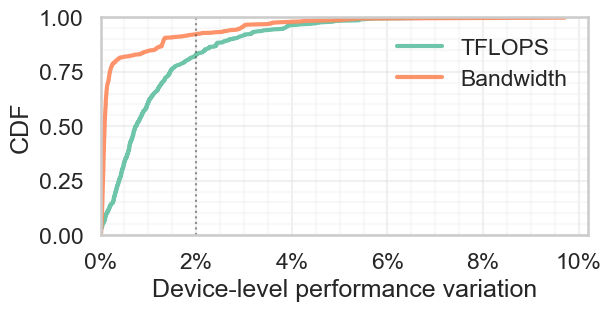

In [8]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter


# Sort values
sorted_fp16_spread = np.sort(stats_display_fp16['fp16_max_min_diff_avg'].values)
sorted_bw_spread = np.sort(stats_bw['bw_max_min_diff_avg'].values)

# CDF
fp16cdf = np.arange(1, len(sorted_fp16_spread) + 1) / len(sorted_fp16_spread)
bwcdf = np.arange(1, len(sorted_bw_spread) + 1) / len(sorted_bw_spread)

# Styling
sns.set_theme(style="whitegrid", context="talk")
colors = sns.color_palette("Set2", 2)
fp16_color, bw_color = colors[0], colors[1]

fig, ax = plt.subplots(figsize=(6, 3), constrained_layout=True)

# CDF curves
ax.plot(sorted_fp16_spread, fp16cdf, color=fp16_color, linewidth=3, label='TFLOPS', alpha=0.95)
ax.plot(sorted_bw_spread, bwcdf, color=bw_color, linewidth=3, label='Bandwidth', alpha=0.95)

# Vertical 2% threshold
ax.axvline(0.02, color='0.3', linestyle=':', linewidth=1.5, alpha=0.6)
# ax.text(0.021, 0.05, '2%', rotation=90, va='bottom', ha='left', color='0.3')

# Axes formatting
ax.set_xlim(left=0)
ax.set_ylim(0, 1)
ax.set_xlabel('Device-level performance variation')
ax.set_ylabel('CDF')
ax.xaxis.set_major_formatter(PercentFormatter(xmax=1, decimals=0))

# Grid + legend
ax.legend(frameon=False)
ax.grid(True, which='major', color='0.9', alpha=0.6)
ax.grid(True, which='minor', color='0.95', alpha=0.5)
ax.minorticks_on()

# Save
fig.savefig('all_cdf.pdf', dpi=600, bbox_inches='tight')
plt.show()
